# CCV Datası Üzərində Vizual Analiz (EDA)

Bu notebook-da CCV datasındakı **kateqorik** və **ədədi** dəyişənlər üzərində Matplotlib və Seaborn istifadə edərək müxtəlif vizuallar çıxarılır. Hər qrafikdən əvvəl onun nə üçün istifadə olunduğu izah edilir.

## 1. Kitabxanaların yüklənməsi və datanın oxunması

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ccv_data.csv')
df

,ID,Yas,Cins,Sehir,Departament,Tehsil,Tecrube_il,Maas,Satis_meblegi,Mennuniyyet_skoru
0,1,32,Kişi,Bakı,IT,Bakalavr,6.6,1605.0,1035.0,7.6
1,2,32,Qadın,Gəncə,HR,Doktorantura,2.8,1168.0,180.0,8.7
2,3,37,Qadın,Gəncə,Marketinq,Magistr,9.0,1526.0,743.0,5.6
3,4,51,Qadın,Gəncə,Marketinq,Bakalavr,10.6,1256.0,592.0,6.0
4,5,51,Kişi,Sumqayıt,Satış,Bakalavr,10.2,1264.0,6275.0,7.5
...,...,...,...,...,...,...,...,...,...,...
295,296,51,Kişi,Bakı,IT,Magistr,14.0,1894.0,736.0,10.0
296,297,52,Qadın,Gəncə,Maliyyə,Bakalavr,7.1,1506.0,808.0,5.7
297,298,21,Qadın,Bakı,Satış,Bakalavr,0.3,1014.0,6287.0,8.8
298,299,52,Kişi,Bakı,Marketinq,Orta,9.9,1161.0,656.0,7.5


In [6]:
df.drop('ID', axis=1, inplace=True)

## 2. Ədədi və kateqorik sütunların ayrılması

Vizualları avtomatik çəkə bilmək üçün ədədi (numeric) və kateqorik (categorical) sütunları ayrıca siyahılara yığırıq.

In [7]:
numeric_cols = df.select_dtypes(exclude='object').columns.to_list()
categorical_cols = df.select_dtypes(include='object').columns.to_list()

## 3. Histogram (paylanma qrafiki)

**Nə üçün istifadə olunur:** Hər bir ədədi dəyişənin necə paylandığını (normal, sağa/sola əyri, çoxpiklidi və s.) görmək üçün istifadə olunur. Data Science-də bu, dəyişənin təbiətini anlamaq və hansı transformasiyaya (məsələn log) ehtiyac olub-olmadığını qərarlaşdırmaq üçün ilk addımlardan biridir.

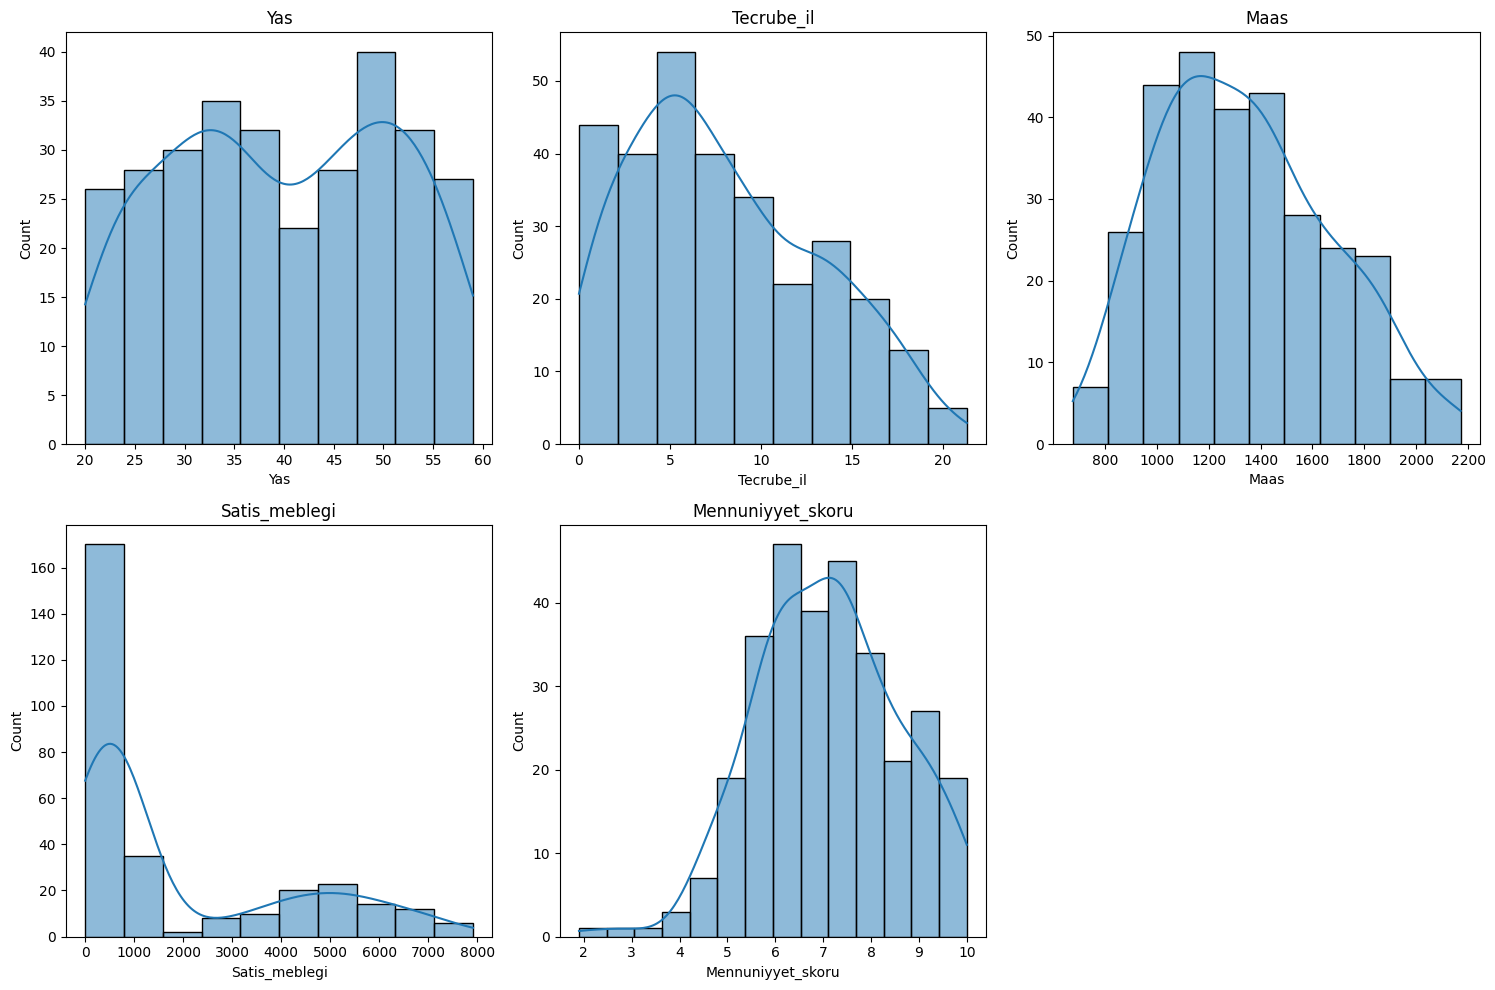

In [10]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

## 4. Boxplot (kənar dəyərlərin aşkarlanması)

**Nə üçün istifadə olunur:** Ədədi dəyişənlərdə outlier (kənar/anomal) dəyərləri tapmaq üçün istifadə olunur. Outlier-lər modelin nəticəsini təhrif edə bilər, ona görə EDA mərhələsində onları görmək vacibdir.

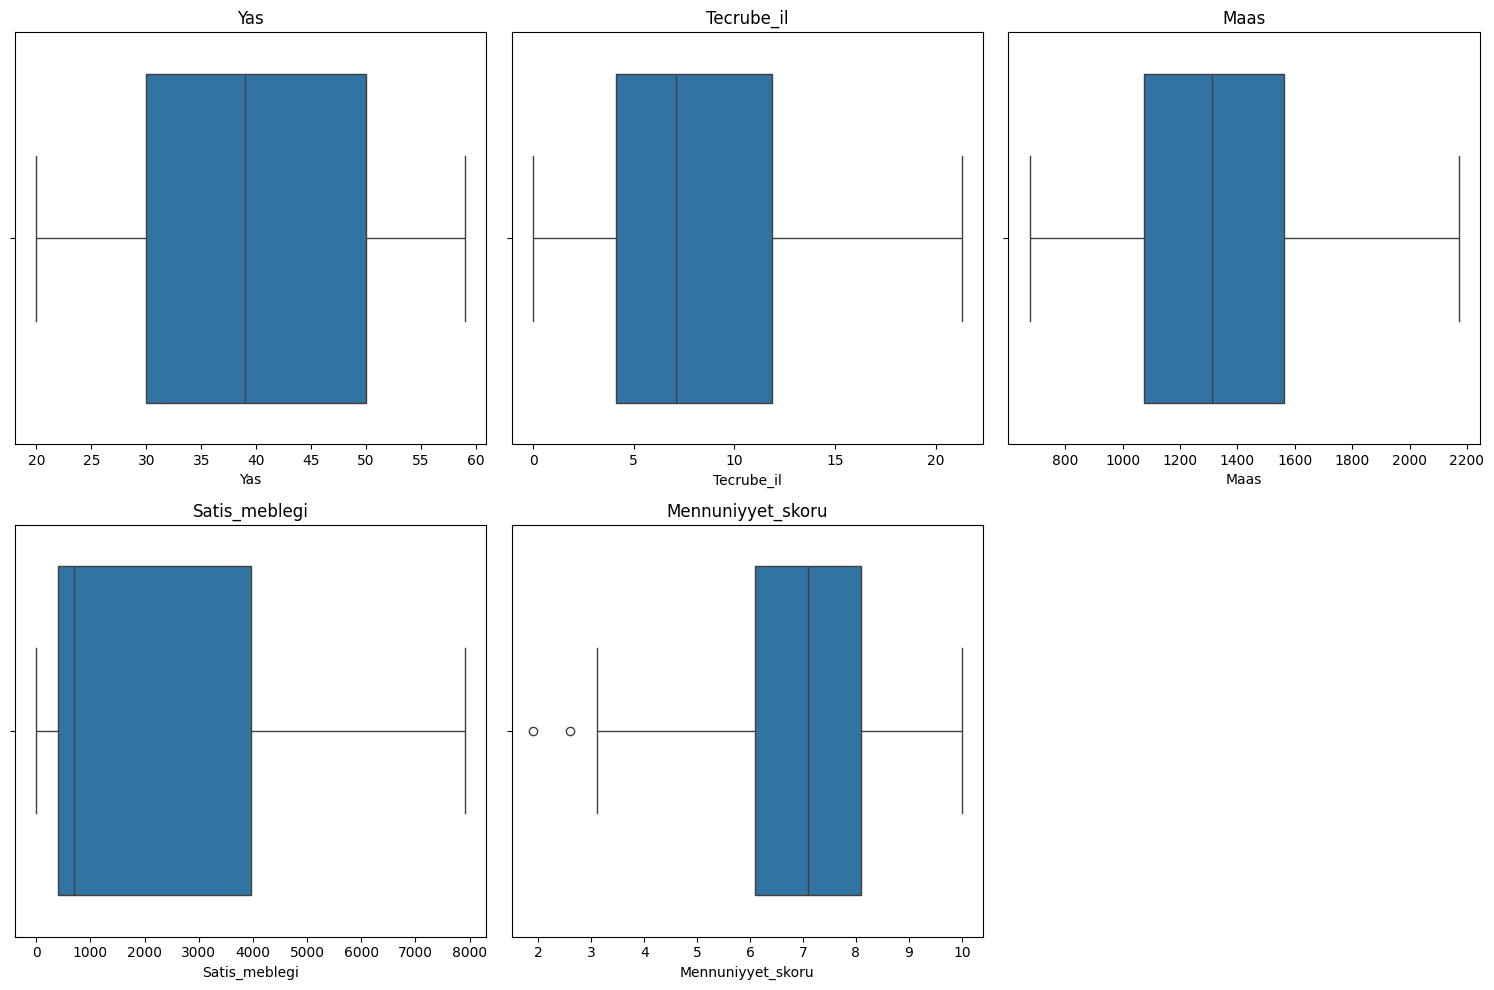

In [11]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## 5. Scatterplot (Maaş ilə əlaqə)

**Nə üçün istifadə olunur:** Digər ədədi dəyişənlərin `Maas` (maaş) ilə necə əlaqəli olduğunu görmək üçün istifadə olunur. Bu, xüsusilə hansı dəyişənlərin gələcəkdə model üçün faydalı ola biləcəyini anlamaqda köməkçidir (əlaqə xətti, müsbət/mənfi trend).

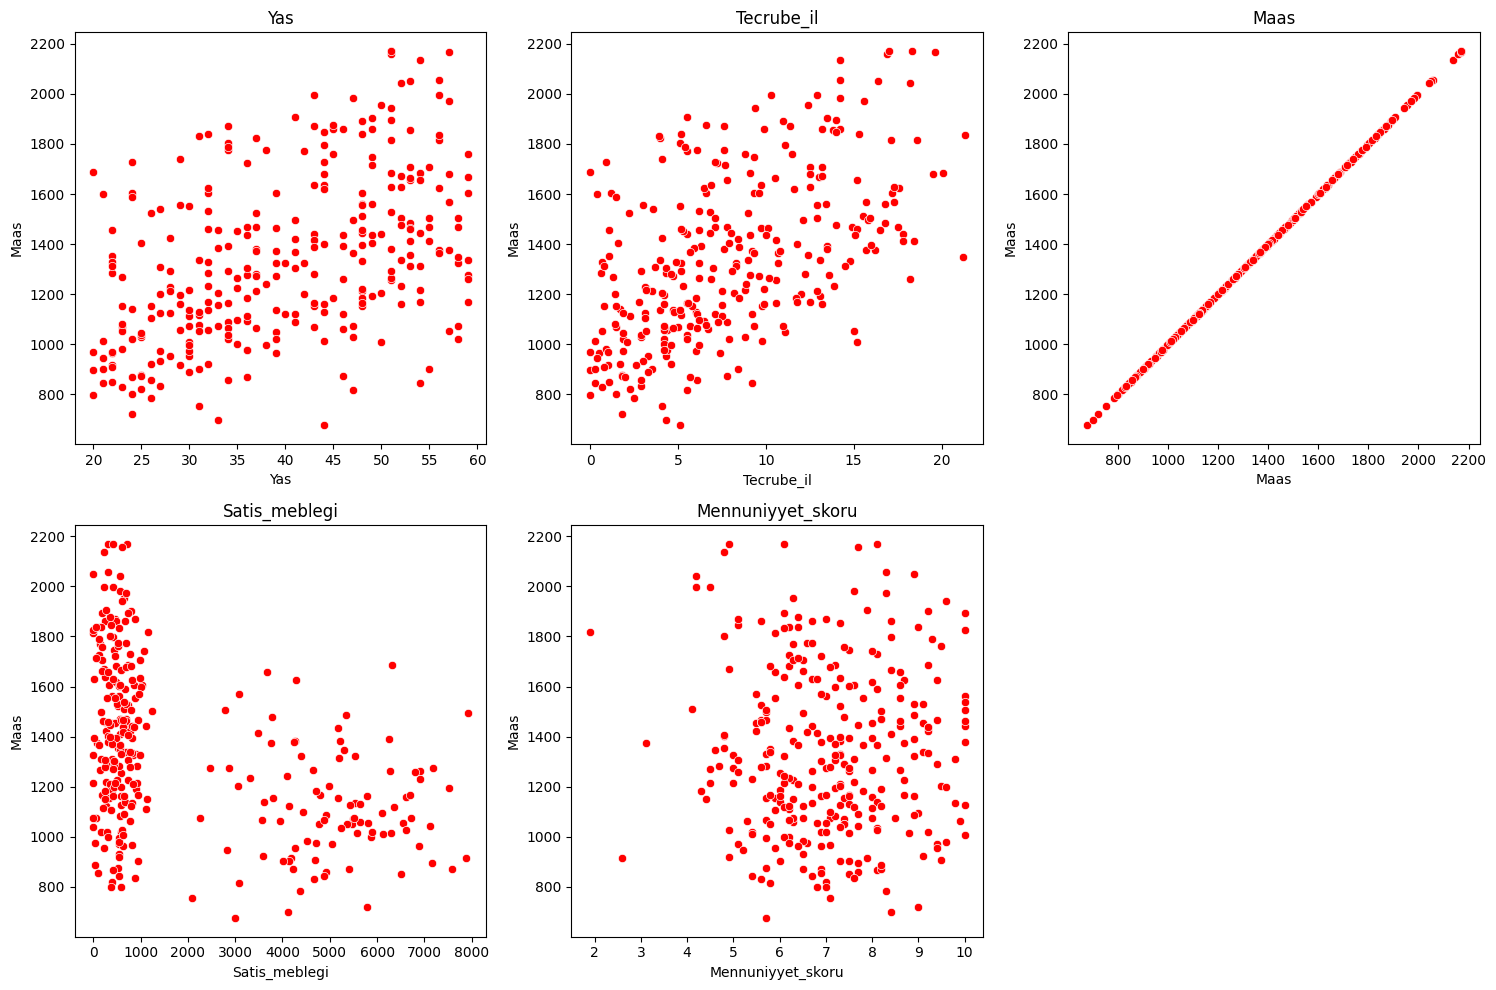

In [15]:

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(x=df[col], y=df['Maas'], color='red')
    plt.title(col)

plt.tight_layout()
plt.show()

## 6. Countplot (kateqorik dəyişənlərin tezliyi)

**Nə üçün istifadə olunur:** Hər kateqorik sütunda hansı kateqoriyanın nə qədər tez-tez rast gəlindiyini göstərir. Balanssız kateqoriyaları (məsələn, bir departamentin çox az sayda olması) erkən görmək üçün faydalıdır.

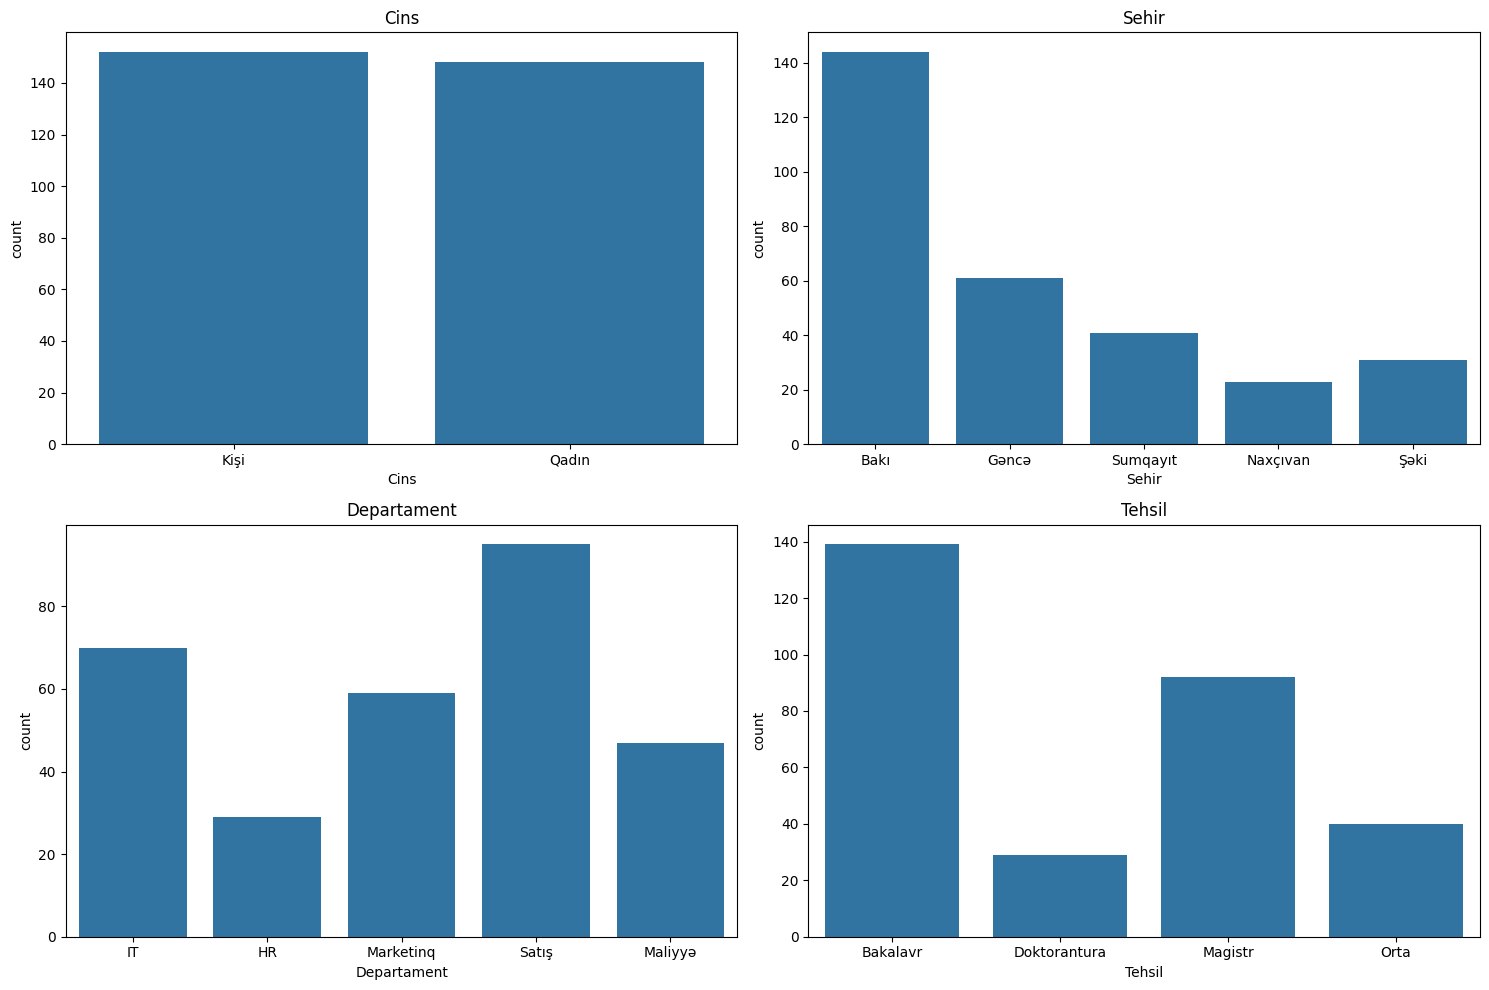

In [16]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(data=df, x=col)
    plt.title(col)

plt.tight_layout()
plt.show()

## 7. Korrelyasiya Heatmap

**Nə üçün istifadə olunur:** Ədədi dəyişənlər arasındakı xətti əlaqənin gücünü (-1 ilə 1 arası) rəngli formada göstərir. Data Science-də bu, hansı dəyişənlərin bir-birini təkrarladığını (multikollinearlıq) və hansıların target ilə güclü əlaqədə olduğunu tapmaq üçün istifadə olunur.

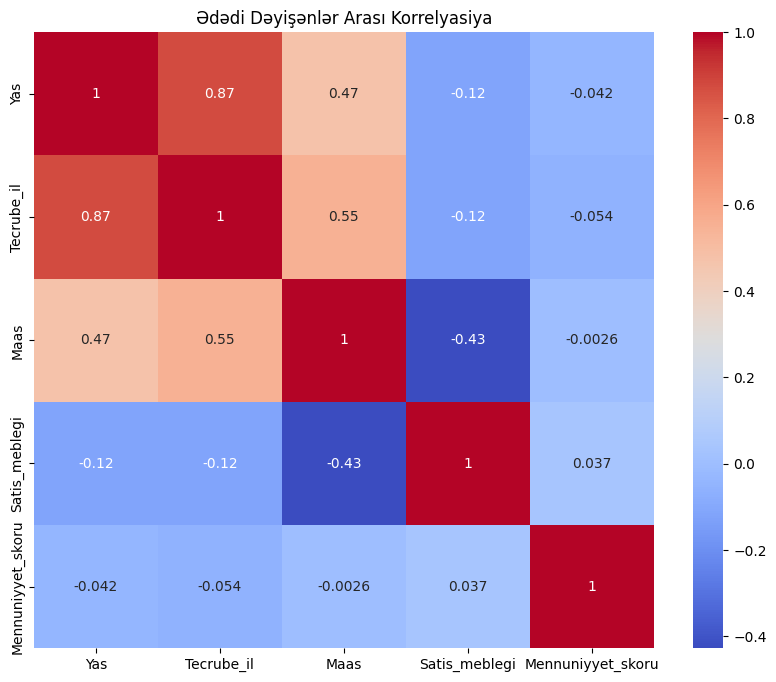

In [17]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Ədədi Dəyişənlər Arası Korrelyasiya')
plt.show()

## 8. Barplot (Departament üzrə orta maaş)

**Nə üçün istifadə olunur:** Kateqoriyalar üzrə orta dəyəri müqayisə etmək üçün istifadə olunur. Burada hansı departamentin orta olaraq daha yüksək maaş aldığını görürük.

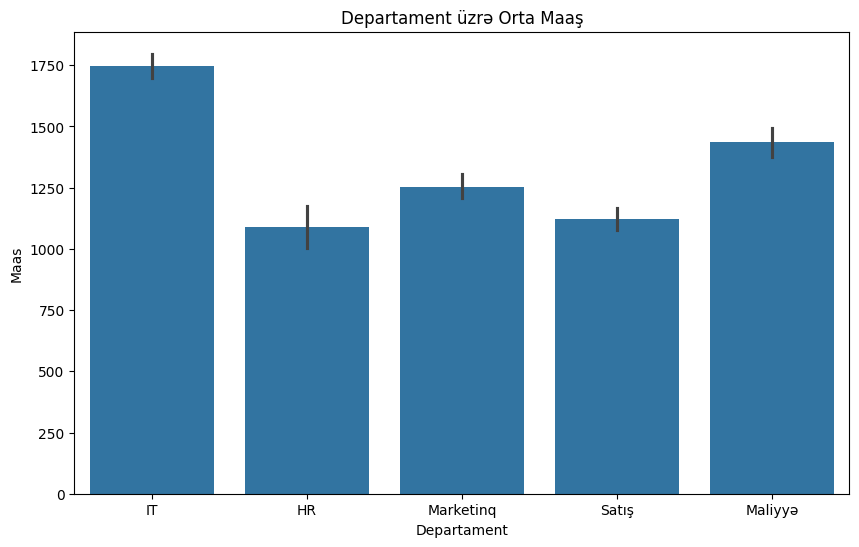

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='Departament',
    y='Maas'
)

plt.title('Departament üzrə Orta Maaş')
plt.show()

## 9. Violinplot (paylanma + boxplot birlikdə)

**Nə üçün istifadə olunur:** Hər kateqoriya üzrə ədədi dəyişənin (Maas) həm paylanma formasını, həm də median/kvartilləri eyni anda göstərir. Boxplot-dan fərqli olaraq paylanmanın forması (sıxlığı) da görünür.

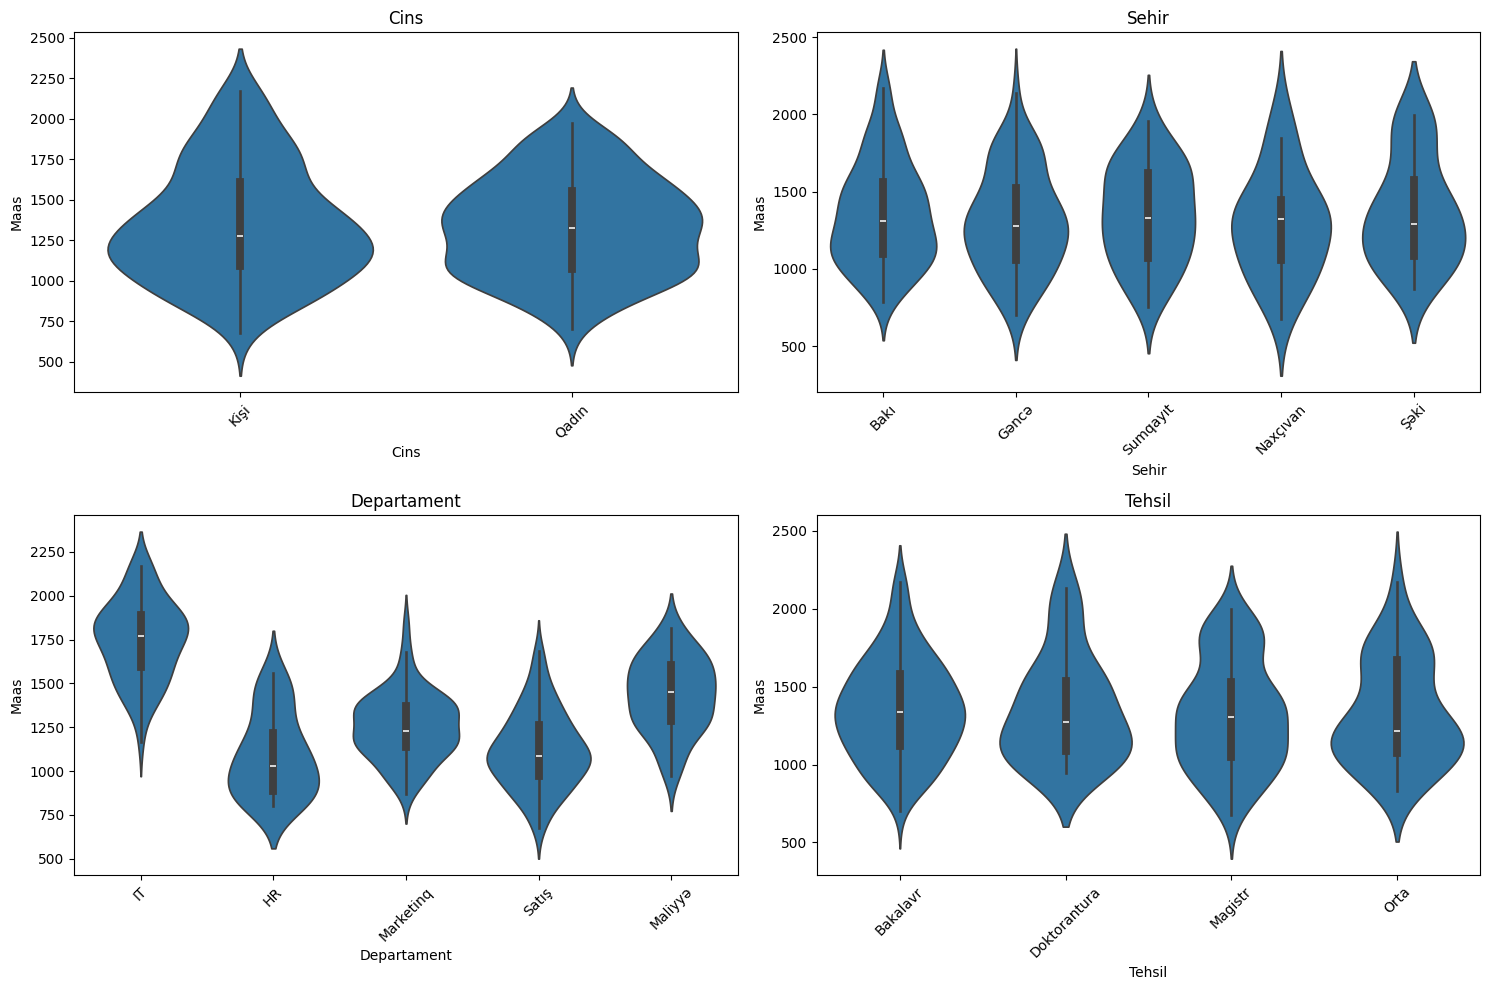

In [19]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i+1)
    sns.violinplot(data=df, x=col, y='Maas')
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

## 10. Stacked Bar Chart (Departament və Təhsil üzrə say)

**Nə üçün istifadə olunur:** İki kateqorik dəyişən arasındakı əlaqəni (crosstab) vizual şəkildə göstərmək üçün istifadə olunur. Məsələn, hansı departamentdə hansı təhsil səviyyəsindən neçə nəfər olduğunu görmək olar.

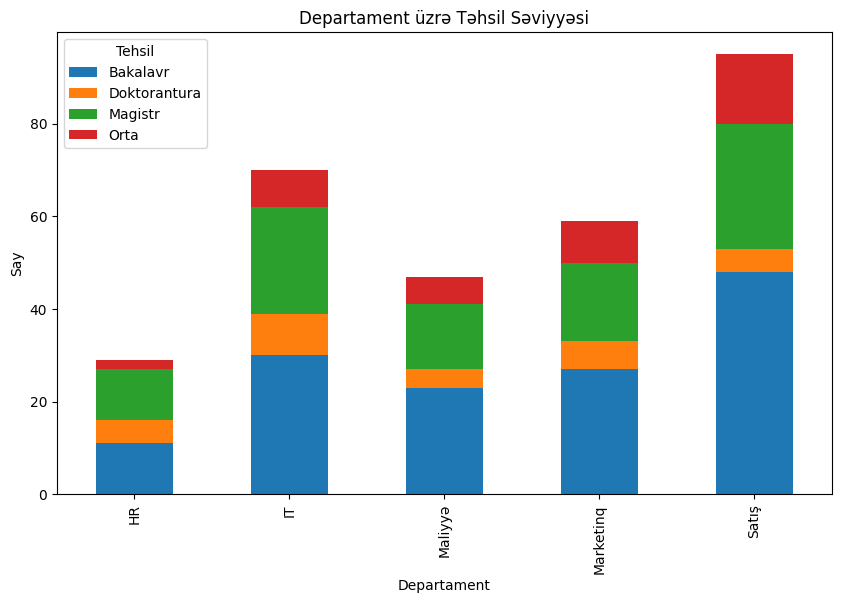

In [20]:
table = pd.crosstab(
    df['Departament'],
    df['Tehsil']
)

table.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Departament üzrə Təhsil Səviyyəsi')
plt.xlabel('Departament')
plt.ylabel('Say')
plt.show()

## 11. Pairplot (bütün ədədi dəyişənlərin qarşılıqlı əlaqəsi)

**Nə üçün istifadə olunur:** Bütün ədədi dəyişən cütlərini eyni anda scatterplot şəklində göstərir və diaqonalda hər dəyişənin paylanmasını verir. Dəyişənlər arası əlaqələri tez bir zamanda ümumi görmək üçün çox istifadə olunur.

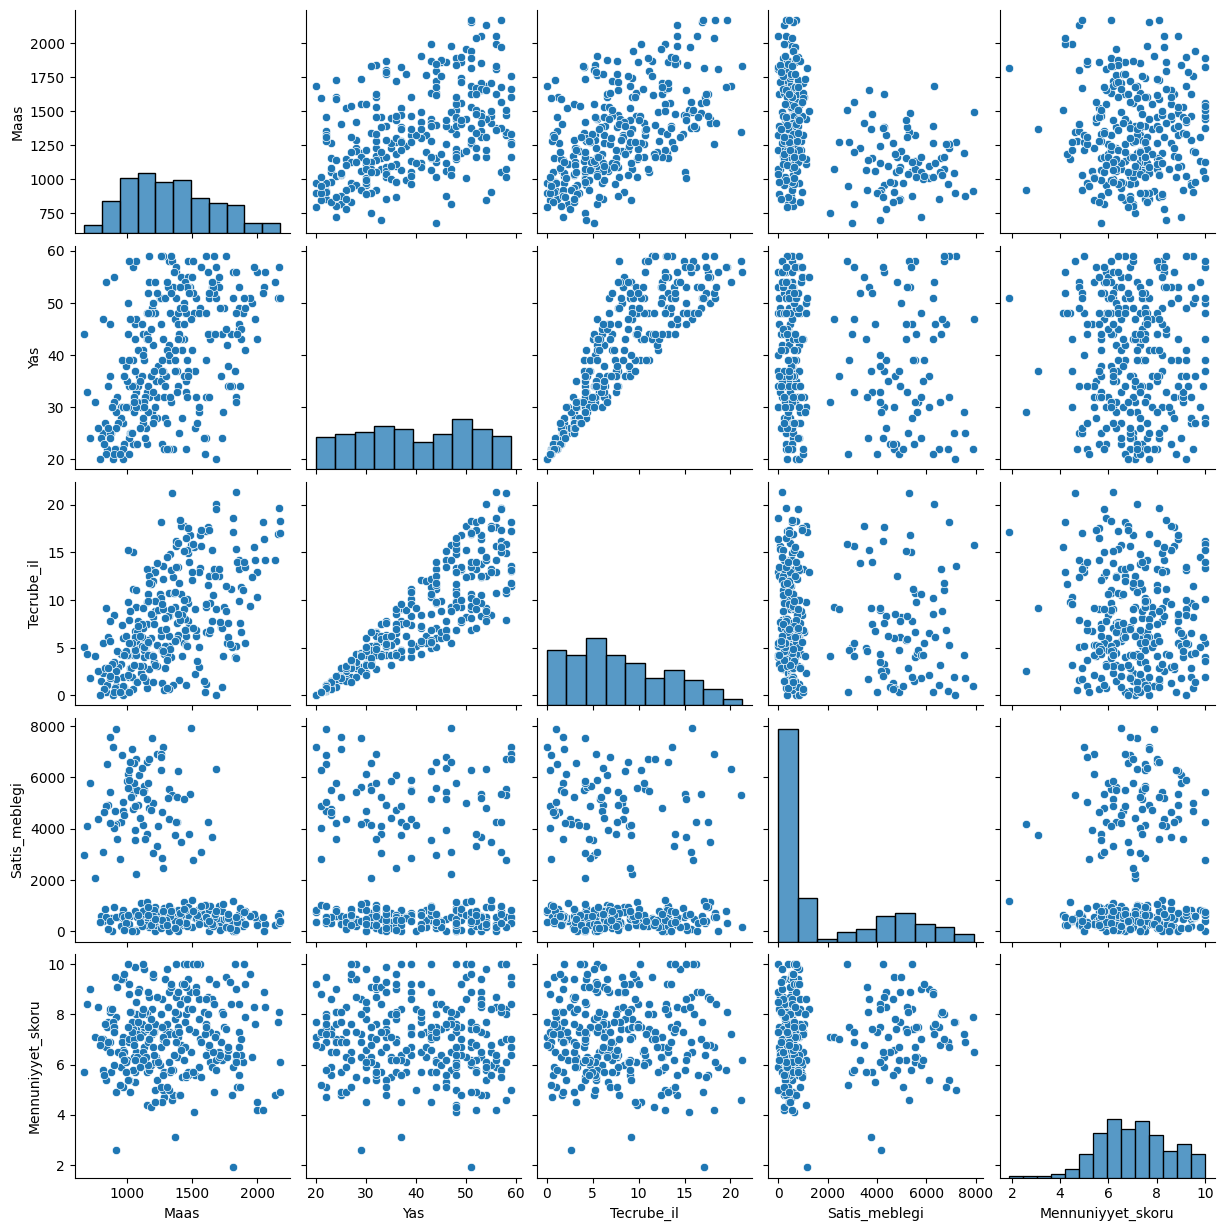

In [21]:
sns.pairplot(
    df[['Maas', 'Yas', 'Tecrube_il', 'Satis_meblegi', 'Mennuniyyet_skoru']]
)

plt.show()

## 12. Lineplot (Təcrübə ilinə görə orta maaş trendi)

**Nə üçün istifadə olunur:** Zaman və ya sıralı ədədi dəyişən artdıqca (burada təcrübə ili) target dəyişənin (maaş) necə dəyişdiyini trend şəklində göstərir.

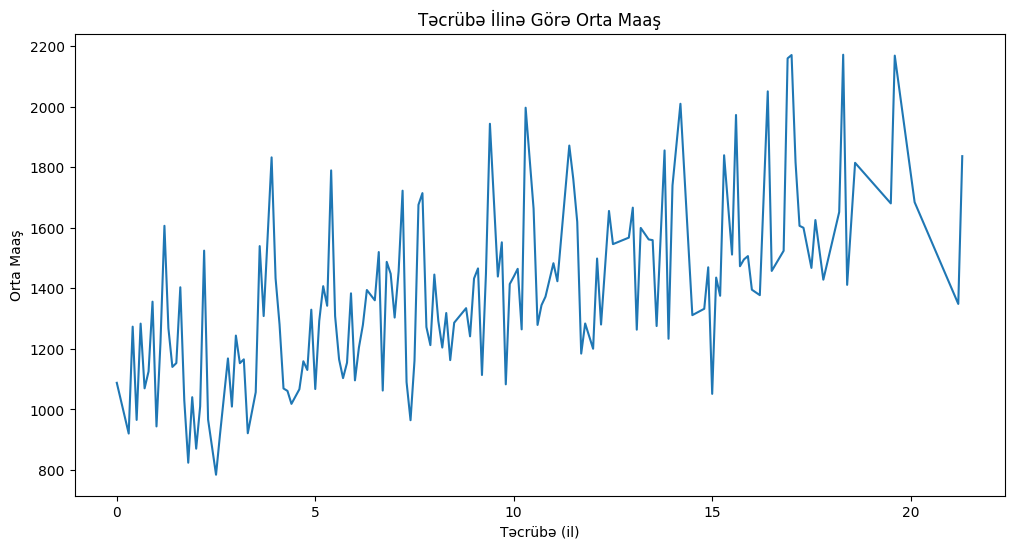

In [22]:
maas_by_tecrube = df.groupby('Tecrube_il')['Maas'].mean()

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=maas_by_tecrube.index,
    y=maas_by_tecrube.values
)

plt.title('Təcrübə İlinə Görə Orta Maaş')
plt.xlabel('Təcrübə (il)')
plt.ylabel('Orta Maaş')
plt.show()

## 13. Pie Chart (Departament paylanması)

**Nə üçün istifadə olunur:** Kateqoriyaların ümumi datadakı faiz payını göstərmək üçün istifadə olunur. Kateqoriya sayı az olduqda oxunaqlı olur.

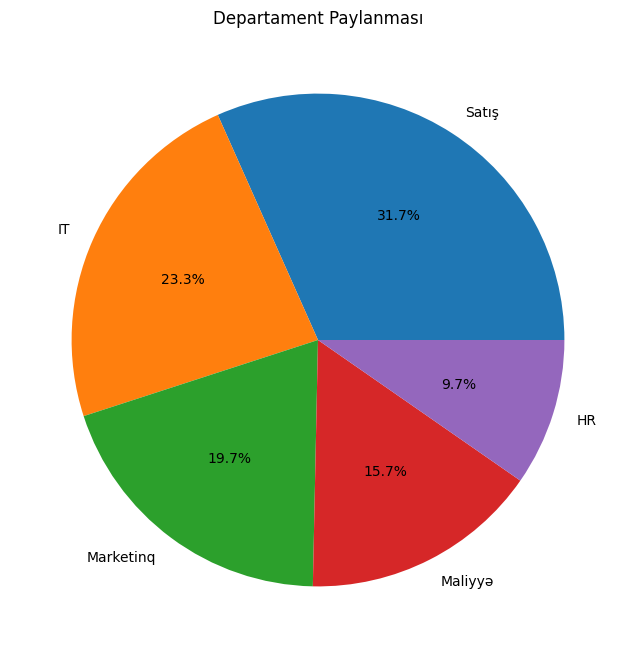

In [23]:
plt.figure(figsize=(8, 8))

df['Departament'].value_counts().plot.pie(
    autopct='%1.1f%%'
)

plt.title('Departament Paylanması')
plt.ylabel('')
plt.show()

## 14. ECDF Plot (kumulyativ paylanma)

**Nə üçün istifadə olunur:** Bir dəyişənin dəyərlərinin neçə faizinin müəyyən bir həddən aşağı/yuxarı olduğunu göstərir. Histogramdan fərqli olaraq paylanmanı kumulyativ formada, dəqiq faizlərlə görmək olur.

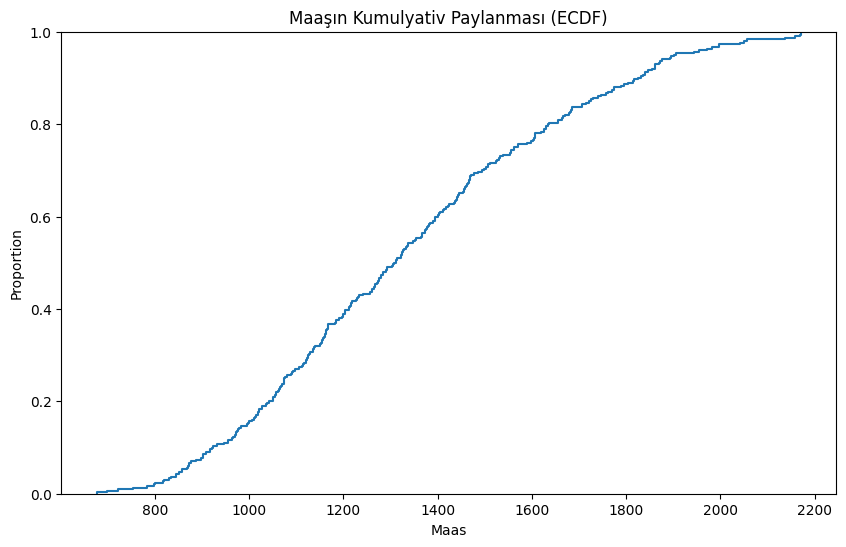

In [24]:
plt.figure(figsize=(10, 6))

sns.ecdfplot(
    data=df,
    x='Maas'
)

plt.title('Maaşın Kumulyativ Paylanması (ECDF)')
plt.show()

## 15. KDE Plot (qruplar üzrə paylanmanın müqayisəsi)

**Nə üçün istifadə olunur:** Fərqli qrupların (burada Cins) eyni ədədi dəyişən üzrə paylanmasını eyni qrafikdə üst-üstə müqayisə etmək üçün istifadə olunur. Bu, iki qrup arasında əhəmiyyətli fərq olub-olmadığını vizual olaraq görməyə kömək edir.

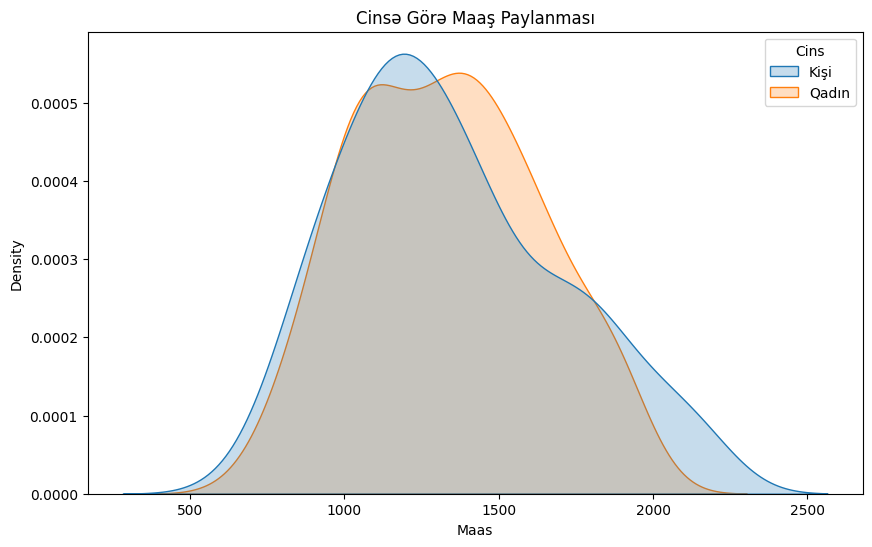

In [25]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='Maas',
    hue='Cins',
    fill=True
)

plt.title('Cinsə Görə Maaş Paylanması')
plt.show()

## 16. Stripplot (Departament üzrə məmnuniyyət skoru)

**Nə üçün istifadə olunur:** Kiçik/orta ölçülü datalarda hər bir müşahidəni ayrıca nöqtə kimi göstərir. Boxplot və violinplot-a nisbətən datanın həqiqi sıxlığını və fərdi dəyərləri daha aydın görmək olur.

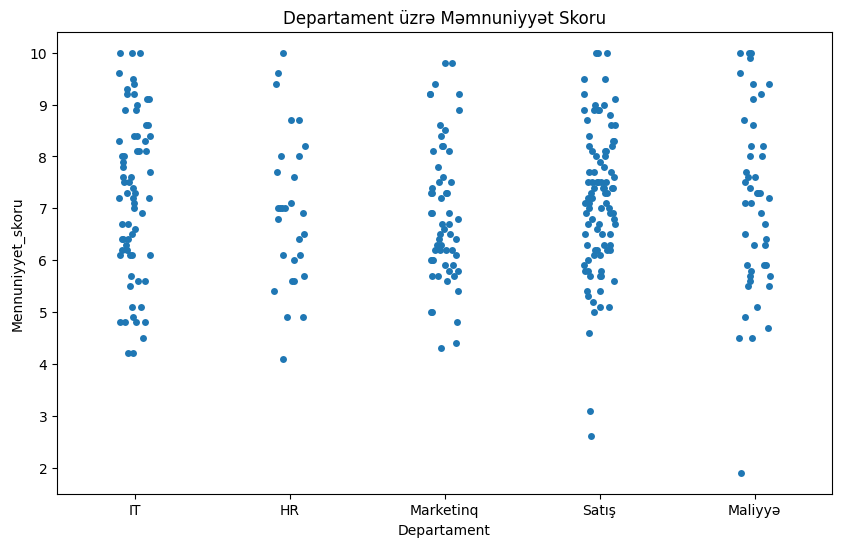

In [26]:
plt.figure(figsize=(10, 6))

sns.stripplot(
    data=df,
    x='Departament',
    y='Mennuniyyet_skoru'
)

plt.title('Departament üzrə Məmnuniyyət Skoru')
plt.show()